In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image

In [8]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')

Not running on Colab — skipping drive.mount.


In [9]:
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'

In [10]:
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                         if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes   = len(label_encoder)
print(f'{num_classes} classes from folder structure.')

52 classes from folder structure.


In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


## Feature extraction — 8 views, summary + patch tokens (v4.1: fine-tuned backbone)

**v4.1 change** — uses the fine-tuned C-RADIO backbone () instead of the frozen hub weights. All other extraction logic (8 views, summary+patch concat, chunked saving) is identical.

**Experiment #2** — rotational TTA: adds 90° and 270° views (coins are rotationally invariant).

**Experiment #3** — patch tokens: RADIO returns `(summary, spatial)`. We mean-pool `spatial` to get a second 2560-d vector and concatenate it with `summary`, giving a **5120-d** feature per image that encodes both global identity and local texture/legend detail.

**Experiment #9** — r512 view: sharper at 512 px, helps with fine legend text.

Each chunk is saved with both `features_summary` and `features_patch`; the cell is fully resumable.

In [12]:
image_dir  = Path(DATA_DIR)
filepaths  = sorted(image_dir.glob('*/side_a/*.jpg'))
raw_labels = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int = [label_encoder[l] for l in raw_labels]
print(f'Total images: {len(filepaths)}')

# (name, resolution, h_flip, rotation_degrees)
VIEWS = [
    ('r256',      256, False,   0),
    ('r256_flip', 256, True,    0),
    ('r256_r90',  256, False,  90),   # exp #2: rotational TTA
    ('r256_r270', 256, False, 270),   # exp #2
    ('r384',      384, False,   0),
    ('r384_flip', 384, True,    0),
    ('r384_r90',  384, False,  90),   # exp #2
    ('r512',      512, False,   0),   # exp #9: high-res view
]
NUM_CHUNKS    = 10
EXTRACT_BATCH = 8

tta_root   = Path(DATA_DIR) / 'cradio_v41_tta_chunks'
final_path = Path(DATA_DIR) / 'cradio_v41_embeddings.pt'
tta_root.mkdir(parents=True, exist_ok=True)


def chunk_ranges(n_total, n_chunks):
    edges = np.linspace(0, n_total, n_chunks + 1, dtype=int)
    return [(i, int(edges[i]), int(edges[i + 1])) for i in range(n_chunks)]


class CoinDataset(Dataset):
    def __init__(self, fps, labs, resolution, flip, rotation):
        self.fps = fps; self.labs = labs
        self.resolution = resolution; self.flip = flip; self.rotation = rotation

    def __len__(self): return len(self.fps)

    def __getitem__(self, i):
        img = Image.open(self.fps[i]).convert('RGB')
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        if self.flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        if self.rotation:
            img = img.rotate(self.rotation, expand=False)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


@torch.no_grad()
def run_chunk(model, sub_fp, sub_lb, resolution, flip, rotation):
    ds     = CoinDataset(sub_fp, sub_lb, resolution, flip, rotation)
    loader = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
    sums, patches, labs = [], [], []
    for j, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, spatial = model(imgs)          # spatial: (B, num_patches, D)
        sums.append(summary.float().cpu())
        patches.append(spatial.float().mean(dim=1).cpu())   # mean-pool patches
        labs.append(l)
        if (j + 1) % 100 == 0:
            print(f'      batch {j + 1}/{len(loader)}')
    return torch.cat(sums), torch.cat(patches), torch.cat(labs)


ranges = chunk_ranges(len(filepaths), NUM_CHUNKS)

if final_path.exists():
    print(f'Final embeddings already exist at {final_path} — skipping extraction.')
else:
    missing = [
        (vname, res, flip, rot, idx, s, e, tta_root / f'{vname}_chunk_{idx:02d}.pt')
        for vname, res, flip, rot in VIEWS
        for idx, s, e in ranges
        if not (tta_root / f'{vname}_chunk_{idx:02d}.pt').exists()
    ]

    if not missing:
        print('All chunks already on disk — skipping backbone load.')
    else:
        print(f'{len(missing)}/{len(VIEWS) * NUM_CHUNKS} chunks remaining. Loading C-RADIO v4-H...')
        radio_model = torch.hub.load('NVlabs/RADIO', 'radio_model',
                                     version='c-radio_v4-h', progress=True)
        radio_model = radio_model.to(device).eval()
        for p in radio_model.parameters():
            p.requires_grad = False
        # v4.1: load fine-tuned backbone weights
        ft_ckpt = torch.load('emp_model_v4_finetuned.pth', map_location=device)
        radio_model.load_state_dict(ft_ckpt['radio'])
        radio_model.eval()
        print('Loaded fine-tuned backbone from emp_model_v4_finetuned.pth')

        for vname, res, flip, rot, idx, start, end, out_path in missing:
            print(f'  view={vname}  chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}')
            t0     = datetime.now()
            sub_fp = [str(p) for p in filepaths[start:end]]
            sub_lb = labels_int[start:end]
            s_f, p_f, labs = run_chunk(radio_model, sub_fp, sub_lb, res, flip, rot)
            torch.save({'features_summary': s_f, 'features_patch': p_f, 'labels': labs},
                       out_path)
            print(f'    saved {out_path.name}  in {datetime.now() - t0}')

        del radio_model
        torch.cuda.empty_cache()

    print('Concatenating + averaging across views...')
    sum_s = None; sum_p = None; label_tensor = None
    for vname, *_ in VIEWS:
        v_s, v_p, v_l = [], [], []
        for idx, *_ in ranges:
            d = torch.load(tta_root / f'{vname}_chunk_{idx:02d}.pt')
            v_s.append(d['features_summary'])
            v_p.append(d['features_patch'])
            v_l.append(d['labels'])
        vs = torch.cat(v_s); vp = torch.cat(v_p)
        sum_s = vs if sum_s is None else sum_s + vs
        sum_p = vp if sum_p is None else sum_p + vp
        if label_tensor is None:
            label_tensor = torch.cat(v_l)

    avg_s    = sum_s / len(VIEWS)
    avg_p    = sum_p / len(VIEWS)
    combined = torch.cat([avg_s, avg_p], dim=-1)   # (N, 5120)
    torch.save({'features': combined, 'labels': label_tensor}, final_path)
    print(f'Saved combined embeddings → {final_path}  shape={combined.shape}')

Total images: 62134
80/80 chunks remaining. Loading C-RADIO v4-H...


Using cache found in /home/david/.cache/torch/hub/NVlabs_RADIO_main
/home/david/.cache/torch/hub/NVlabs_RADIO_main/hubconf.py:80: UserWarning: Unexpected keys in state dict: ['patch_generator._vis_cond.norm_mean', 'patch_generator._vis_cond.norm_std']
  warnings.warn(f'Unexpected keys in state dict: {key_warn.unexpected_keys}')


Loaded fine-tuned backbone from emp_model_v4_finetuned.pth
  view=r256  chunk 1/10  rows 0:6213
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_00.pt  in 0:01:05.191550
  view=r256  chunk 2/10  rows 6213:12426
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_01.pt  in 0:01:05.223342
  view=r256  chunk 3/10  rows 12426:18640
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_02.pt  in 0:01:04.617564
  view=r256  chunk 4/10  rows 18640:24853
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_03.pt  in 0:00:58.258729
  view=r256  chunk 5/10  rows 24853

In [13]:
saved = torch.load(final_path)
all_feats, all_labs = saved['features'], saved['labels']
print(f'V4 embeddings: {all_feats.shape}')   # (62134, 5120)

V4 embeddings: torch.Size([62134, 3840])


In [14]:
MERGES = {'GORDIAN II': 'GORDIAN I'}

remap  = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names        = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new        = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs      = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'After merge: {num_classes} classes.')

After merge: 51 classes.


In [15]:
train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

print(f'Train: {train_feats.shape[0]}  Val: {val_feats.shape[0]}  Test: {test_feats.shape[0]}')
print(f'Feature dim: {train_feats.shape[1]}')

class_counts = torch.bincount(train_labs, minlength=num_classes).float()
beta         = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights   = (1.0 - beta) / effective_num
cb_weights   = cb_weights / cb_weights.sum() * num_classes
cb_weights   = cb_weights.to(device)
print('Class-balanced weights ready.')

Train: 39765  Val: 9942  Test: 12427
Feature dim: 3840
Class-balanced weights ready.


In [16]:
batch_size     = 512
sample_weights = cb_weights.cpu()[train_labs]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_labs), replacement=True)
train_loader   = DataLoader(TensorDataset(train_feats, train_labs),
                             batch_size=batch_size, sampler=train_sampler)
val_loader     = DataLoader(TensorDataset(val_feats,   val_labs),   batch_size=batch_size, shuffle=False)
test_loader    = DataLoader(TensorDataset(test_feats,  test_labs),  batch_size=batch_size, shuffle=False)
print('Loaders ready.')

Loaders ready.


In [17]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((name_to_prefix.get(name, 99), name,
                 int(train_c.get(cls_idx, 0)),
                 int(val_c.get(cls_idx, 0)),
                 int(test_c.get(cls_idx, 0))))
rows.sort()
per_class_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
per_class_counts['Total'] = per_class_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(per_class_counts.to_string(index=False))

 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1074  269   336   1679
 2          TIBERIUS    527  132   165    824
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    882  221   276   1379
 5              NERO    926  232   290   1448
 6             GALBA    991  248   310   1549
 7              OTHO    411  103   129    643
 8         VITELLIUS    568  142   178    888
 9         VESPASIAN   1361  340   425   2126
10             TITUS   1121  280   350   1751
11          DOMITIAN   1309  327   409   2045
12             NERVA   1105  276   345   1726
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   245   1227
18          COMMODUS   1122  281   351   1754
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   158    792
21  SEPTIMUS SEVERUS   1501  375  

## Model — ArcFace classifier + wider head

**Experiment #4** — ArcFace loss: adds a fixed angular margin `m` to the target class angle before softmax, forcing the model to learn tighter, more separated clusters in embedding space.

**Experiment #11** — Ensemble diversity: each of the 10 heads uses a slightly different hidden size / dropout / mixup-alpha, so the ensemble members make different errors and the average is more robust.

In [18]:
class ArcFaceClassifier(nn.Module):
    """Cosine classifier with additive angular margin.

    margin=0.2 is intentionally mild so it stays compatible with mixup.
    scale=20 matches v3's CosineClassifier range.
    """
    def __init__(self, in_dim, n_cls, scale=20.0, margin=0.2):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim))
        nn.init.xavier_uniform_(self.weight)
        self.scale  = scale
        self.margin = margin

    def forward(self, x, labels=None):
        x   = F.normalize(x, dim=-1)
        w   = F.normalize(self.weight, dim=-1)
        cos = x @ w.T                                          # (B, C)
        if labels is None or not self.training:
            return self.scale * cos
        theta      = cos.clamp(-1 + 1e-7, 1 - 1e-7).acos()
        target_cos = (theta + self.margin).cos()
        one_hot    = torch.zeros_like(cos).scatter_(1, labels.unsqueeze(1), 1.0)
        return self.scale * (one_hot * target_cos + (1 - one_hot) * cos)


class CoinHeadV4(nn.Module):
    """3-layer MLP head feeding into ArcFace classifier."""
    def __init__(self, in_dim, n_cls, hidden=2048, dropout=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls)

    def forward(self, x, labels=None):
        return self.cls(self.body(x), labels)


feat_dim = train_feats.shape[1]
print(f'Head: {feat_dim} → 2048 → 2048 → 1024 → ArcFace[{num_classes}]  (scale=20, margin=0.2)')

Head: 3840 → 2048 → 2048 → 1024 → ArcFace[51]  (scale=20, margin=0.2)


## Training utilities

**Experiment #6** — Cluster-aware hard mixup: with probability `hard_prob`, each mixed pair is drawn from the same confusion cluster (emperors that looked visually similar in v3 results). This forces the head to learn the fine discriminating features within each hard group.

In [19]:
# Hard confusion clusters derived from v3 per-class analysis
HARD_CLUSTERS = [
    ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
    ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
    ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
    ['CARACALLA', 'GETA', 'ELAGABALUS', 'SEVERUS ALEXANDER'],
    ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
    ['PHILIP THE ARAB', 'TRAJAN DECIUS', 'TRBONIANUS GALLUS'],
    ['VESPASIAN', 'TITUS'],
    ['NUMERIAN', 'CARINUS', 'CARUS'],
]

# (num_classes, num_classes) boolean: True if same hard cluster
cluster_affinity = torch.zeros(num_classes, num_classes, dtype=torch.bool)
for cluster in HARD_CLUSTERS:
    idxs = [label_encoder[n] for n in cluster if n in label_encoder]
    for a in idxs:
        for b in idxs:
            if a != b:
                cluster_affinity[a, b] = True


def cluster_aware_mixup(x, y, alpha=0.3, hard_prob=0.4):
    """Standard Beta mixup, but hard_prob of the time pairs come from the same
    confusion cluster so the head must learn fine within-cluster discrimination."""
    lam = float(np.random.beta(alpha, alpha))
    B   = x.size(0)
    idx = torch.randperm(B, device=x.device)

    if np.random.random() < hard_prob:
        affinities = cluster_affinity[y.cpu()]          # (B, C)
        for i in range(B):
            partners = (affinities[i, y.cpu()] & (torch.arange(B) != i)).nonzero(as_tuple=True)[0]
            if len(partners) > 0:
                idx[i] = partners[torch.randint(len(partners), (1,))]

    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def arcface_mixup_loss(logits, y_a, y_b, lam, weight, smoothing=0.05):
    log_p = F.log_softmax(logits, dim=-1)
    def one(y):
        nll    = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        per_ex = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per_ex = per_ex * weight[y]
        return per_ex.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [20]:
# Uniform configs — diversity via seed and dropout only.
# All use α≤0.2 so ArcFace margin stays stable on mixed inputs.
HEAD_CONFIGS = [
    # (seed, hidden, dropout, mixup_alpha, lr,   weight_decay)
    (2000, 2048, 0.30, 0.20, 3e-4, 1e-2),
    (2001, 2048, 0.25, 0.15, 3e-4, 1e-2),
    (2002, 2048, 0.30, 0.20, 2e-4, 5e-3),
    (2003, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (2004, 2048, 0.30, 0.15, 3e-4, 1e-2),
    (2005, 2048, 0.25, 0.20, 4e-4, 1e-2),
    (2006, 2048, 0.30, 0.20, 3e-4, 5e-3),
    (2007, 2048, 0.35, 0.15, 2e-4, 1e-2),
    (2008, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (2009, 2048, 0.30, 0.20, 3e-4, 2e-2),
]
EPOCHS = 100


def train_one_head(seed, hidden=2048, dropout=0.3, mixup_alpha=0.2,
                   lr=3e-4, weight_decay=1e-2, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model     = CoinHeadV4(feat_dim, num_classes, hidden=hidden, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, epochs * steps_per_epoch,
                                warmup_steps=2 * steps_per_epoch)
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running = 0.0
        for feats, targets in train_loader:
            feats, targets = feats.to(device), targets.to(device)
            mixed, y_a, y_b, lam = cluster_aware_mixup(feats, targets, alpha=mixup_alpha,
                                                         hard_prob=0.2)
            optimizer.zero_grad()
            # Only apply ArcFace margin when mix is light (lam > 0.5 → dominant label is y_a).
            # For heavy mixes the input is genuinely ambiguous and the margin fires on the wrong target.
            margin_labels = y_a if lam > 0.5 else None
            logits = model(mixed, margin_labels)
            loss   = arcface_mixup_loss(logits, y_a, y_b, lam, cb_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += loss.item()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for feats, targets in val_loader:
                feats, targets = feats.to(device), targets.to(device)
                v_correct += (model(feats).argmax(-1) == targets).sum().item()
                v_total   += targets.size(0)
        val_acc  = v_correct / v_total
        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 10 == 0 or improved):
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'loss {running / len(train_loader):.4f}  '
                  f'val {val_acc:.4f}  lr {lr_now:.2e}  '
                  f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

    model.load_state_dict(best_state)
    return model, best_val_acc


ensemble = []
for k, (seed, hidden, dropout, alpha, lr, wd) in enumerate(HEAD_CONFIGS):
    print(f'\n=== Head {k + 1}/{len(HEAD_CONFIGS)}  '
          f'hidden={hidden} drop={dropout} α={alpha} lr={lr:.0e} ===')
    m, vacc = train_one_head(seed, hidden, dropout, alpha, lr, wd,
                              verbose=(k == 0))
    print(f'  → best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], 'emp_model_v4_ensemble.pth')
print(f'\nSaved {len(ensemble)} heads → emp_model_v4_ensemble.pth')


=== Head 1/10  hidden=2048 drop=0.3 α=0.2 lr=3e-04 ===
[seed 2000] ep   1/100  loss 2.9737  val 0.8683  lr 1.50e-04  [0:00:02.571064] <--
[seed 2000] ep   2/100  loss 1.7865  val 0.8574  lr 3.00e-04  [0:00:02.669364]
[seed 2000] ep   3/100  loss 1.5397  val 0.8892  lr 3.00e-04  [0:00:01.303599] <--
[seed 2000] ep   4/100  loss 1.5573  val 0.8905  lr 3.00e-04  [0:00:03.399787] <--
[seed 2000] ep   5/100  loss 1.4318  val 0.8905  lr 2.99e-04  [0:00:01.320762]
[seed 2000] ep   9/100  loss 1.4253  val 0.8992  lr 2.96e-04  [0:00:01.169856] <--
[seed 2000] ep  10/100  loss 1.1705  val 0.9082  lr 2.95e-04  [0:00:00.988299] <--
[seed 2000] ep  13/100  loss 1.2054  val 0.9104  lr 2.91e-04  [0:00:01.135668] <--
[seed 2000] ep  18/100  loss 1.2282  val 0.9126  lr 2.81e-04  [0:00:01.173906] <--
[seed 2000] ep  20/100  loss 1.1373  val 0.9097  lr 2.76e-04  [0:00:01.283614]
[seed 2000] ep  21/100  loss 1.1119  val 0.9134  lr 2.73e-04  [0:00:01.368447] <--
[seed 2000] ep  25/100  loss 1.1069  val 0.

## Inference — three-way fusion

**Experiment #8** — Prototype kNN: replaces the raw K-NN over all 39K training points with cosine similarity to each class's *mean* prototype embedding. Prototypes are less noisy than individual examples and the lookup is 1000× faster.

**Experiment #7** — Per-class kNN temperature: hard classes (QUINTILLUS, VALERIAN, AEMILIAN …) get a lower softmax temperature so the kNN distribution is softer, reducing overconfident wrong predictions.

Final prediction = `(1-α_p-α_k) × ensemble + α_p × proto_kNN + α_k × raw_kNN`

In [21]:
@torch.no_grad()
def ensemble_probs(feats):
    feats  = feats.to(device)
    probs  = None
    for m in ensemble:
        p     = F.softmax(m(feats), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


# ---- Prototype kNN — exp #8 ----
train_norm_all = F.normalize(train_feats.to(device), dim=-1)
train_labs_dev = train_labs.to(device)

prototypes = torch.zeros(num_classes, feat_dim, device=device)
for c in range(num_classes):
    mask = train_labs_dev == c
    if mask.sum() > 0:
        prototypes[c] = F.normalize(train_norm_all[mask].mean(0), dim=-1)
print(f'Prototypes: {prototypes.shape}')


# ---- Per-class temperature — exp #7 ----
HARD_CLASS_NAMES = {
    'QUINTILLUS', 'VALERIAN', 'AEMILIAN', 'GALLIENUS',
    'SEPTIMUS SEVERUS', 'CLAUDIUS GOTHICUS', 'AURELIAN',
}
GLOBAL_TEMP   = 20.0
HARD_TEMP     = 8.0     # softer distribution for visually ambiguous classes
per_class_temp = torch.full((num_classes,), GLOBAL_TEMP, device=device)
for name in HARD_CLASS_NAMES:
    if name in label_encoder:
        per_class_temp[label_encoder[name]] = HARD_TEMP
print('Per-class temperatures set.')


@torch.no_grad()
def proto_knn_probs(feats):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ prototypes.T                         # (B, C)
    # apply per-class temperature: scale each column by its temp then softmax
    scaled = sims * per_class_temp.unsqueeze(0)     # (B, C)
    return F.softmax(scaled, dim=-1)


@torch.no_grad()
def raw_knn_probs(feats, K=25, temperature=20.0):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ train_norm_all.T
    vals, idx = sims.topk(K, dim=-1)
    weights   = F.softmax(vals * temperature, dim=-1)
    neigh_labs = train_labs_dev[idx]
    out = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, neigh_labs, weights)
    return out


@torch.no_grad()
def fused_predict(feats, ap=0.2, ak=0.1):
    """ap = proto-kNN weight, ak = raw-kNN weight."""
    e = ensemble_probs(feats)
    p = proto_knn_probs(feats)
    k = raw_knn_probs(feats)
    return (1 - ap - ak) * e + ap * p + ak * k

Prototypes: torch.Size([51, 3840])
Per-class temperatures set.


In [22]:
# Grid search over fusion weights on validation set
print('Sweeping fusion weights on val set...')
results = {}
for ap in [0.0, 0.1, 0.2, 0.3]:
    for ak in [0.0, 0.1, 0.2]:
        if ap + ak > 0.6:
            continue
        correct, total = 0, 0
        for feats, targets in val_loader:
            targets = targets.to(device)
            probs   = fused_predict(feats, ap, ak)
            correct += (probs.argmax(-1) == targets).sum().item()
            total   += targets.size(0)
        results[(ap, ak)] = correct / total
        print(f'  α_proto={ap:.1f}  α_knn={ak:.1f}  → val={correct / total:.4f}')

best_ap, best_ak = max(results, key=results.get)
print(f'\nBest: α_proto={best_ap}  α_knn={best_ak}  val={results[(best_ap, best_ak)]:.4f}')

Sweeping fusion weights on val set...
  α_proto=0.0  α_knn=0.0  → val=0.9210
  α_proto=0.0  α_knn=0.1  → val=0.9210
  α_proto=0.0  α_knn=0.2  → val=0.9211
  α_proto=0.1  α_knn=0.0  → val=0.9212
  α_proto=0.1  α_knn=0.1  → val=0.9209
  α_proto=0.1  α_knn=0.2  → val=0.9213
  α_proto=0.2  α_knn=0.0  → val=0.9212
  α_proto=0.2  α_knn=0.1  → val=0.9212
  α_proto=0.2  α_knn=0.2  → val=0.9214
  α_proto=0.3  α_knn=0.0  → val=0.9212
  α_proto=0.3  α_knn=0.1  → val=0.9213
  α_proto=0.3  α_knn=0.2  → val=0.9218

Best: α_proto=0.3  α_knn=0.2  val=0.9218


In [23]:
def evaluate(loader, name, ap=best_ap, ak=best_ak):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs   = fused_predict(feats, ap, ak)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'{name}: {acc:.4f}  ({correct}/{total})')
    return acc

print('--- Ensemble only ---')
evaluate(val_loader,  'Val  ', 0.0, 0.0)
evaluate(test_loader, 'Test ', 0.0, 0.0)

print(f'\n--- Ensemble + proto-kNN + raw-kNN (α_p={best_ap}, α_k={best_ak}) ---')
evaluate(val_loader,  'Val  ')
evaluate(test_loader, 'Test ')

--- Ensemble only ---
Val  : 0.9210  (9157/9942)
Test : 0.9196  (11428/12427)

--- Ensemble + proto-kNN + raw-kNN (α_p=0.3, α_k=0.2) ---
Val  : 0.9218  (9165/9942)
Test : 0.9194  (11426/12427)


0.919449585579786

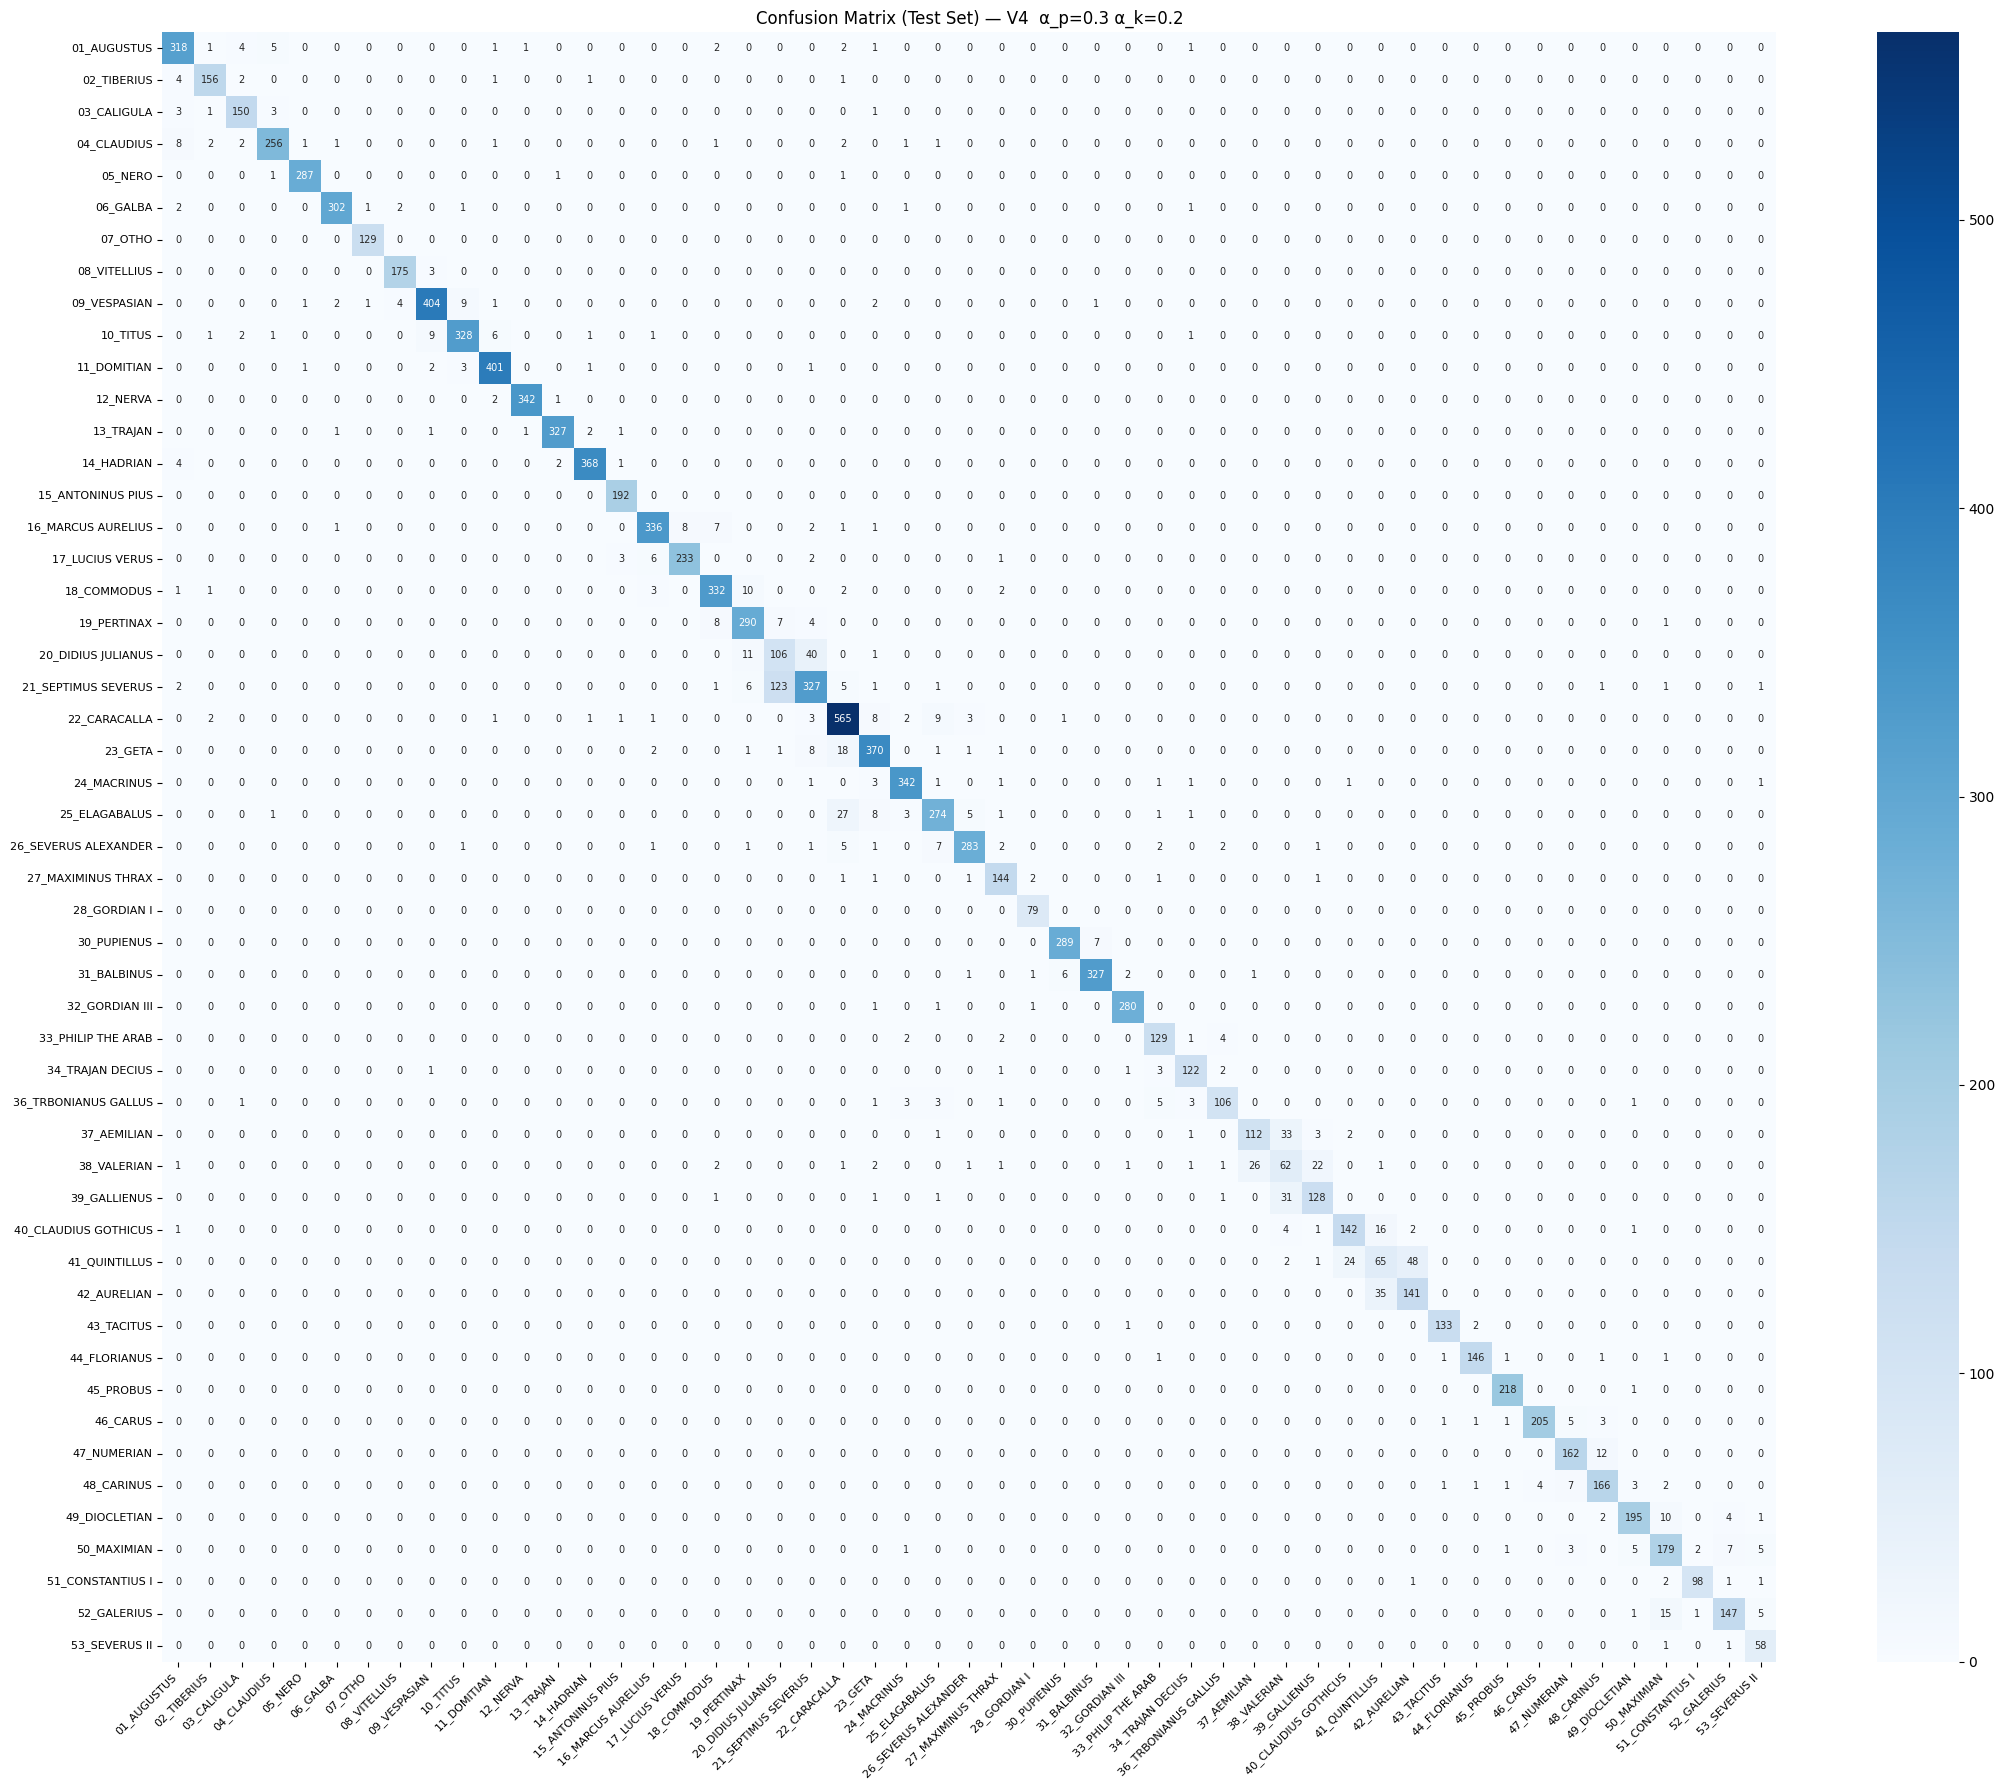

In [24]:
class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        targets = targets.to(device)
        preds   = fused_predict(feats, best_ap, best_ak).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — V4  α_p={best_ap} α_k={best_ak}')
plt.tight_layout()
plt.show()

In [25]:
TOP_CONFUSIONS = 3
total_correct  = int(cm.diagonal().sum())
total          = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct / total:.4f}')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
for i in np.argsort(row_acc):
    n_total   = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc       = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total}  acc={acc:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  → {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  → other: {remaining}')

Overall test accuracy: 11426/12427 = 0.9194

41_QUINTILLUS: 65/140  acc=0.464
  → 42_AURELIAN: 48 (34.3%)
  → 40_CLAUDIUS GOTHICUS: 24 (17.1%)
  → 38_VALERIAN: 2 (1.4%)
  → other: 1

38_VALERIAN: 62/122  acc=0.508
  → 37_AEMILIAN: 26 (21.3%)
  → 39_GALLIENUS: 22 (18.0%)
  → 18_COMMODUS: 2 (1.6%)
  → other: 10

20_DIDIUS JULIANUS: 106/158  acc=0.671
  → 21_SEPTIMUS SEVERUS: 40 (25.3%)
  → 19_PERTINAX: 11 (7.0%)
  → 23_GETA: 1 (0.6%)

21_SEPTIMUS SEVERUS: 327/469  acc=0.697
  → 20_DIDIUS JULIANUS: 123 (26.2%)
  → 19_PERTINAX: 6 (1.3%)
  → 22_CARACALLA: 5 (1.1%)
  → other: 8

37_AEMILIAN: 112/152  acc=0.737
  → 38_VALERIAN: 33 (21.7%)
  → 39_GALLIENUS: 3 (2.0%)
  → 40_CLAUDIUS GOTHICUS: 2 (1.3%)
  → other: 2

39_GALLIENUS: 128/163  acc=0.785
  → 38_VALERIAN: 31 (19.0%)
  → 18_COMMODUS: 1 (0.6%)
  → 23_GETA: 1 (0.6%)
  → other: 2

42_AURELIAN: 141/176  acc=0.801
  → 41_QUINTILLUS: 35 (19.9%)

40_CLAUDIUS GOTHICUS: 142/167  acc=0.850
  → 41_QUINTILLUS: 16 (9.6%)
  → 38_VALERIAN: 4 (2.4%)
  

## Hierarchical classifier — Experiment #10

Stage 1 predicts which *dynasty / period* the coin belongs to (9 groups). This is a much easier problem and should hit >98 % accuracy. Stage 2 uses that prediction as a soft mask over the emperor probabilities: emperors outside the predicted period get down-weighted, reducing cross-period confusions like SEPTIMIUS SEVERUS → DIDIUS JULIANUS.

Final prediction blends the flat ensemble result with the dynasty-guided result.

In [26]:
DYNASTIES = {
    'JULIO_CLAUDIAN': ['AUGUSTUS', 'TIBERIUS', 'CALIGULA', 'CLAUDIUS', 'NERO'],
    'YEAR_OF_FOUR':   ['GALBA', 'OTHO', 'VITELLIUS'],
    'FLAVIAN':        ['VESPASIAN', 'TITUS', 'DOMITIAN'],
    'NERVA_ANTONINE': ['NERVA', 'TRAJAN', 'HADRIAN', 'ANTONINUS PIUS',
                       'MARCUS AURELIUS', 'LUCIUS VERUS'],
    'COMMODUS_CHAOS': ['COMMODUS', 'PERTINAX', 'DIDIUS JULIANUS'],
    'SEVERAN':        ['SEPTIMUS SEVERUS', 'CARACALLA', 'GETA', 'MACRINUS',
                       'ELAGABALUS', 'SEVERUS ALEXANDER'],
    'CRISIS_EARLY':   ['MAXIMINUS THRAX', 'GORDIAN I', 'PUPIENUS', 'BALBINUS',
                       'GORDIAN III', 'PHILIP THE ARAB', 'TRAJAN DECIUS',
                       'TRBONIANUS GALLUS', 'AEMILIAN'],
    'CRISIS_LATE':    ['VALERIAN', 'GALLIENUS', 'CLAUDIUS GOTHICUS', 'QUINTILLUS',
                       'AURELIAN', 'TACITUS', 'FLORIANUS', 'PROBUS',
                       'CARUS', 'NUMERIAN', 'CARINUS'],
    'TETRARCHY':      ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
}

dynasty_names   = sorted(DYNASTIES.keys())
dynasty_encoder = {d: i for i, d in enumerate(dynasty_names)}
emperor_to_dynasty = {e: d for d, emps in DYNASTIES.items() for e in emps}

# Map emperor index → dynasty index (fallback to first dynasty if somehow missing)
dynasty_of = torch.tensor(
    [dynasty_encoder.get(emperor_to_dynasty.get(idx_to_label[i], ''), 0)
     for i in range(num_classes)], dtype=torch.long
)
n_dynasties = len(dynasty_names)

def to_dynasty(emp_labs):
    return dynasty_of[emp_labs]

train_dyn_loader = DataLoader(
    TensorDataset(train_feats, to_dynasty(train_labs)),
    batch_size=512, sampler=train_sampler)
val_dyn_loader   = DataLoader(
    TensorDataset(val_feats,  to_dynasty(val_labs)),
    batch_size=512, shuffle=False)

print(f'{n_dynasties} dynasties:')
for i, d in enumerate(dynasty_names):
    print(f'  {i}: {d}  ({len(DYNASTIES[d])} emperors)')

9 dynasties:
  0: COMMODUS_CHAOS  (3 emperors)
  1: CRISIS_EARLY  (9 emperors)
  2: CRISIS_LATE  (11 emperors)
  3: FLAVIAN  (3 emperors)
  4: JULIO_CLAUDIAN  (5 emperors)
  5: NERVA_ANTONINE  (6 emperors)
  6: SEVERAN  (6 emperors)
  7: TETRARCHY  (5 emperors)
  8: YEAR_OF_FOUR  (3 emperors)


In [27]:
torch.manual_seed(42)
stage1 = nn.Sequential(
    nn.LayerNorm(feat_dim),
    nn.Linear(feat_dim, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, n_dynasties),
).to(device)

opt1   = torch.optim.AdamW(stage1.parameters(), lr=3e-4, weight_decay=1e-2)
sched1 = make_scheduler(opt1, 60 * len(train_dyn_loader),
                         warmup_steps=2 * len(train_dyn_loader))

best_dyn_acc, best_dyn_state = 0.0, None
for epoch in range(1, 61):
    stage1.train()
    for feats, dyn_targets in train_dyn_loader:
        feats, dyn_targets = feats.to(device), dyn_targets.to(device)
        opt1.zero_grad()
        F.cross_entropy(stage1(feats), dyn_targets).backward()
        opt1.step(); sched1.step()

    stage1.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for feats, dyn_targets in val_dyn_loader:
            feats, dyn_targets = feats.to(device), dyn_targets.to(device)
            correct += (stage1(feats).argmax(-1) == dyn_targets).sum().item()
            total   += dyn_targets.size(0)
    acc = correct / total
    if acc > best_dyn_acc:
        best_dyn_acc  = acc
        best_dyn_state = copy.deepcopy(stage1.state_dict())
    if epoch % 10 == 0:
        print(f'  ep {epoch:2d}/60  val dynasty acc={acc:.4f}')

stage1.load_state_dict(best_dyn_state)
stage1.eval()
print(f'Best dynasty val acc: {best_dyn_acc:.4f}')

  ep 10/60  val dynasty acc=0.9557
  ep 20/60  val dynasty acc=0.9576
  ep 30/60  val dynasty acc=0.9575
  ep 40/60  val dynasty acc=0.9546
  ep 50/60  val dynasty acc=0.9556
  ep 60/60  val dynasty acc=0.9549
Best dynasty val acc: 0.9583


In [28]:
# Soft dynasty mask: dynasty_mask[d, c] = True if emperor c belongs to dynasty d
dynasty_mask = torch.zeros(n_dynasties, num_classes, dtype=torch.float, device=device)
for dyn, emps in DYNASTIES.items():
    d_idx = dynasty_encoder[dyn]
    for e in emps:
        if e in label_encoder:
            dynasty_mask[d_idx, label_encoder[e]] = 1.0


@torch.no_grad()
def hierarchical_predict(feats, ap=best_ap, ak=best_ak, hier_weight=0.3):
    """Blend flat prediction with a dynasty-guided re-ranking.

    The dynasty classifier outputs a distribution over 9 periods.
    We use that as a soft mask over emperor logits — emperors outside
    the predicted period are down-weighted proportionally.
    """
    flat       = fused_predict(feats, ap, ak)              # (B, C)
    dyn_probs  = F.softmax(stage1(feats.to(device)), dim=-1)   # (B, D)
    soft_mask  = dyn_probs @ dynasty_mask                   # (B, C)
    soft_mask  = soft_mask / (soft_mask.sum(dim=-1, keepdim=True) + 1e-8)
    guided     = flat * soft_mask
    guided     = guided / (guided.sum(dim=-1, keepdim=True) + 1e-8)
    return (1 - hier_weight) * flat + hier_weight * guided


print('Sweeping hier_weight on val set...')
best_hw, best_hw_acc = 0.0, 0.0
for hw in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    correct, total = 0, 0
    for feats, targets in val_loader:
        targets = targets.to(device)
        probs   = hierarchical_predict(feats, hier_weight=hw)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'  hier_weight={hw:.1f}  val acc={acc:.4f}')
    if acc > best_hw_acc:
        best_hw_acc = acc; best_hw = hw

print(f'\nBest hier_weight: {best_hw}  val={best_hw_acc:.4f}')

Sweeping hier_weight on val set...
  hier_weight=0.0  val acc=0.9218
  hier_weight=0.1  val acc=0.9219
  hier_weight=0.2  val acc=0.9217
  hier_weight=0.3  val acc=0.9215
  hier_weight=0.4  val acc=0.9218
  hier_weight=0.5  val acc=0.9218

Best hier_weight: 0.1  val=0.9219


In [29]:
print('=== FINAL V4 RESULTS ===')
print('\n--- Flat fusion only ---')
for name, loader in [('Val  ', val_loader), ('Test ', test_loader)]:
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        correct += (fused_predict(feats, best_ap, best_ak).argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    print(f'  {name}: {correct / total:.4f}  ({correct}/{total})')

print(f'\n--- Flat + hierarchical (hier_weight={best_hw}) ---')
for name, loader in [('Val  ', val_loader), ('Test ', test_loader)]:
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        correct += (hierarchical_predict(feats, hier_weight=best_hw).argmax(-1)
                    == targets).sum().item()
        total   += targets.size(0)
    print(f'  {name}: {correct / total:.4f}  ({correct}/{total})')

=== FINAL V4 RESULTS ===

--- Flat fusion only ---
  Val  : 0.9218  (9165/9942)
  Test : 0.9194  (11426/12427)

--- Flat + hierarchical (hier_weight=0.1) ---
  Val  : 0.9219  (9166/9942)
  Test : 0.9205  (11439/12427)
